# Paso 5: EDA Bivariado y Multivariado - Análisis de Transacciones Bancarias

Este notebook contiene el análisis exploratorioA exploratorio bivariado/multivariado (relación entre variables) del dataset de transacciones bancarias.

**Objetivo**: Detectar patrones y diferencias entre variables (ej.: monto por canal y por tipo de transacción) para entender comportamientos “fuera de lo normal”, sin limpieza ni modelado.

# Importacion de librerias
importamos las librerias necesarias para el analisis.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Configurar matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Crear directorio para guardar figuras si no existe
os.makedirs('outputs/figures', exist_ok=True)

print("✓ Librerías importadas y configuración lista")

✓ Librerías importadas y configuración lista


## Cargar Dataset

Verificamos si ya existe `df` en el entorno. Si no existe, lo cargamos desde el archivo CSV.

In [21]:
df = pd.read_csv('../data/transacciones_banco.csv')
print(f"✓ Dataset cargado desde archivo: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✓ Dataset cargado desde archivo: 2,512 filas × 16 columnas


## Preparación de Datos: Parsear Fecha

Convertimos la columna TransactionDate a formato datetime para análisis temporal.

In [22]:
# Parsear TransactionDate a datetime
df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

print(f"✓ TransactionDate parseada correctamente")
print(f"Rango de fechas: {df['TransactionDate_dt'].min()} a {df['TransactionDate_dt'].max()}")
print(f"Valores nulos en fecha: {df['TransactionDate_dt'].isna().sum()}")

✓ TransactionDate parseada correctamente
Rango de fechas: 2023-01-02 16:00:06 a 2024-01-01 18:21:50
Valores nulos en fecha: 0


# Análisis Bivariado: Numérica vs Categórica

Exploramos cómo las variables numéricas se distribuyen según diferentes categorías.

## TransactionAmount por Channel

Analizamos cómo varía el monto de transacciones según el canal utilizado.

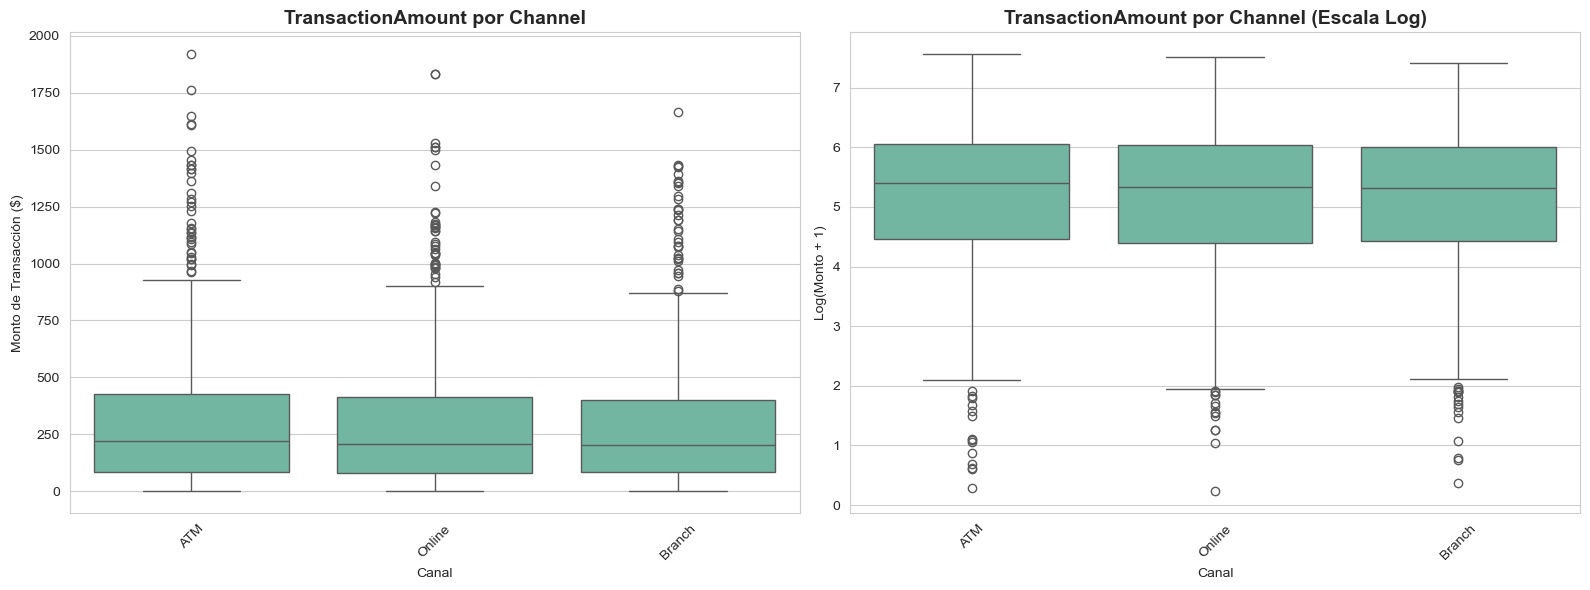


Estadísticas de TransactionAmount por Channel:
         count        mean         std   min      25%     50%      75%  \
Channel                                                                  
ATM      833.0  307.720804  303.512346  0.32  84.8900  218.96  427.690   
Branch   868.0  288.229263  279.188898  0.45  83.1975  204.16  401.935   
Online   811.0  297.214723  293.203307  0.26  79.3400  206.63  414.630   

             max  
Channel           
ATM      1919.11  
Branch   1664.33  
Online   1831.02  


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot normal
sns.boxplot(data=df, x='Channel', y='TransactionAmount', ax=axes[0])
axes[0].set_title('TransactionAmount por Channel', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Monto de Transacción ($)')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot con escala logarítmica
df_temp = df[df['TransactionAmount'] > 0].copy()
df_temp['TransactionAmount_log'] = np.log1p(df_temp['TransactionAmount'])
sns.boxplot(data=df_temp, x='Channel', y='TransactionAmount_log', ax=axes[1])
axes[1].set_title('TransactionAmount por Channel (Escala Log)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Log(Monto + 1)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/figures/amount_by_channel.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas descriptivas por canal
print("\nEstadísticas de TransactionAmount por Channel:")
print(df.groupby('Channel')['TransactionAmount'].describe())

## TransactionAmount por TransactionType

Comparamos los montos de transacciones según el tipo (Credit/Debit).

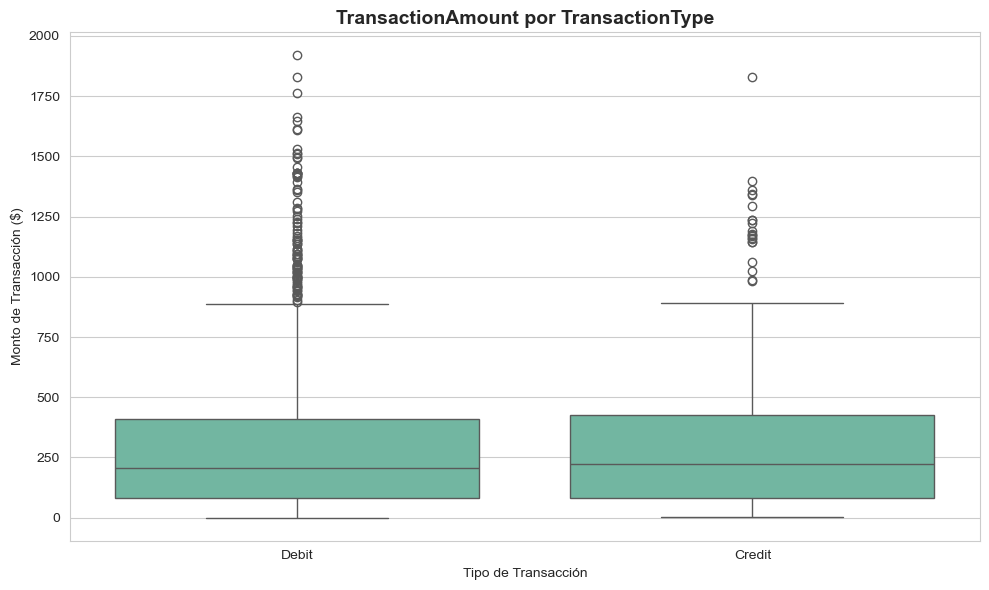


Estadísticas de TransactionAmount por TransactionType:
                  count        mean         std   min      25%     50%  \
TransactionType                                                          
Credit            568.0  306.501004  290.027618  2.03  80.0125  223.36   
Debit            1944.0  294.991255  292.527512  0.26  83.1375  205.14   

                     75%      max  
TransactionType                    
Credit           425.220  1831.02  
Debit            407.785  1919.11  


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', ax=ax)
ax.set_title('TransactionAmount por TransactionType', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Transacción')
ax.set_ylabel('Monto de Transacción ($)')

plt.tight_layout()
plt.savefig('outputs/figures/amount_by_type.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas descriptivas por tipo
print("\nEstadísticas de TransactionAmount por TransactionType:")
print(df.groupby('TransactionType')['TransactionAmount'].describe())

## TransactionAmount por CustomerOccupation

Exploramos las diferencias en montos de transacciones según la ocupación del cliente.

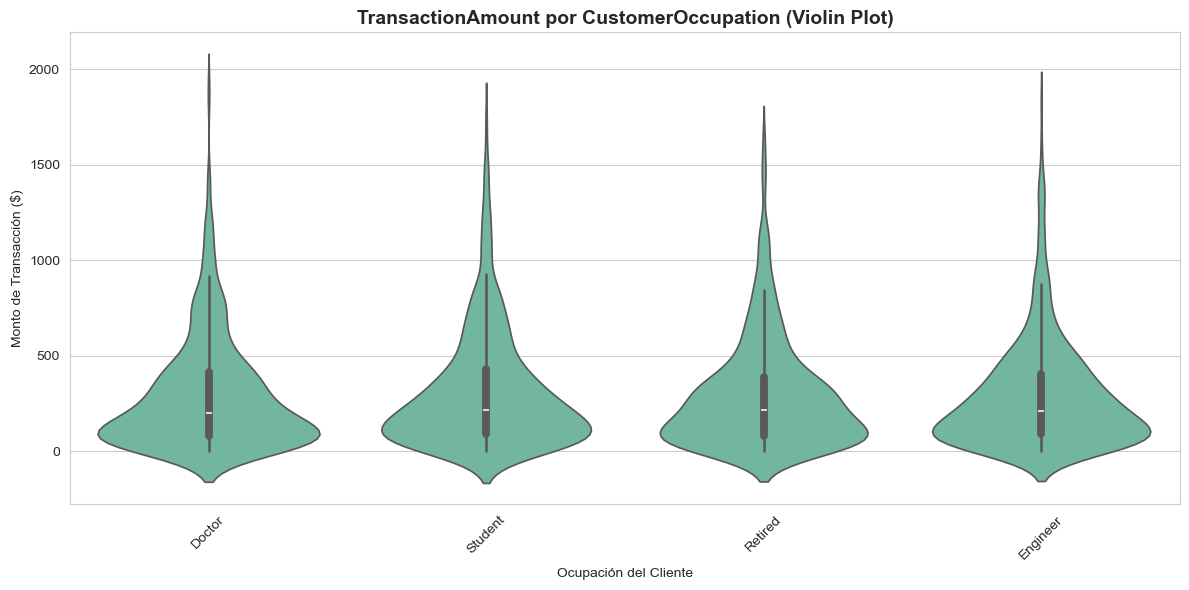


Estadísticas de TransactionAmount por CustomerOccupation:
                          mean  median         std  count
CustomerOccupation                                       
Student             313.220746  215.94  304.616874    657
Retired             294.533673  213.33  286.268759    599
Engineer            289.040096  211.36  283.162514    625
Doctor              292.700174  199.09  292.450174    631


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df, x='CustomerOccupation', y='TransactionAmount', ax=ax)
ax.set_title('TransactionAmount por CustomerOccupation (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ocupación del Cliente')
ax.set_ylabel('Monto de Transacción ($)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por ocupación
print("\nEstadísticas de TransactionAmount por CustomerOccupation:")
print(df.groupby('CustomerOccupation')['TransactionAmount'].agg(['mean', 'median', 'std', 'count']).sort_values('median', ascending=False))

## LoginAttempts por Channel

Analizamos los intentos de login según el canal de transacción utilizado.

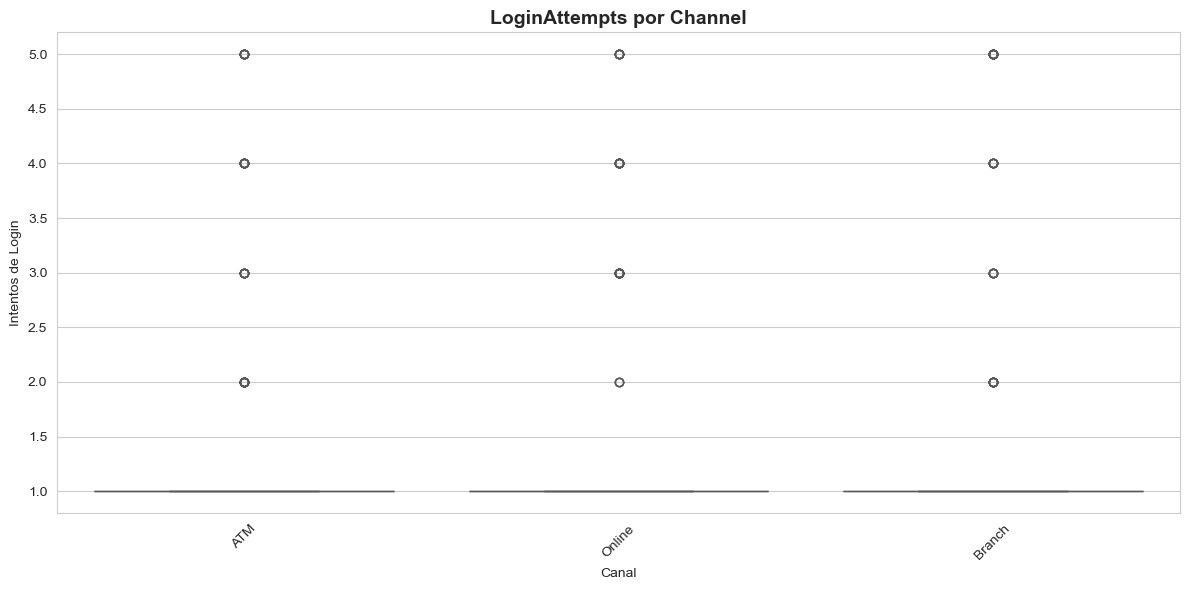


Estadísticas de LoginAttempts por Channel:
         count      mean       std  min  25%  50%  75%  max
Channel                                                    
ATM      833.0  1.123649  0.586573  1.0  1.0  1.0  1.0  5.0
Branch   868.0  1.122120  0.625354  1.0  1.0  1.0  1.0  5.0
Online   811.0  1.128237  0.594899  1.0  1.0  1.0  1.0  5.0


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df, x='Channel', y='LoginAttempts', ax=ax)
ax.set_title('LoginAttempts por Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('Intentos de Login')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/figures/login_attempts_by_channel.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas de LoginAttempts por Channel:")
print(df.groupby('Channel')['LoginAttempts'].describe())

# Análisis Bivariado: Numérica vs Numérica

Exploramos las relaciones entre variables numéricas mediante scatterplots y correlaciones.

## Scatterplot: TransactionAmount vs AccountBalance

Exploramos la relación entre el monto de transacción y el saldo de cuenta.

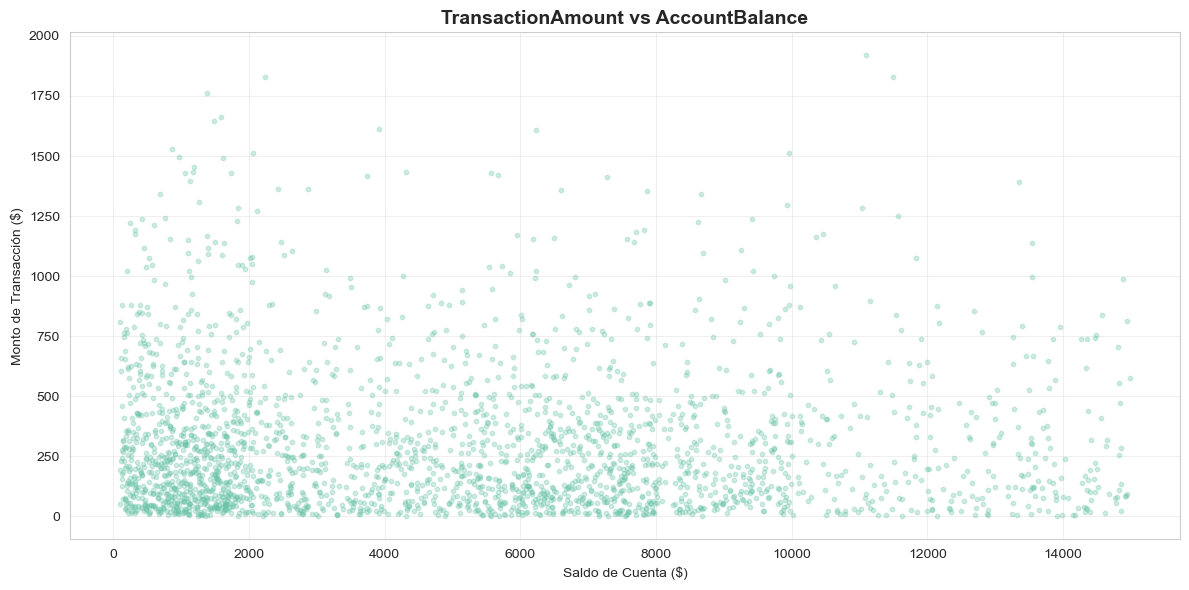


Correlación de Pearson: -0.0252


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df['AccountBalance'], df['TransactionAmount'], alpha=0.3, s=10)
ax.set_title('TransactionAmount vs AccountBalance', fontsize=14, fontweight='bold')
ax.set_xlabel('Saldo de Cuenta ($)')
ax.set_ylabel('Monto de Transacción ($)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/amount_vs_balance_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

# Correlación
corr = df[['TransactionAmount', 'AccountBalance']].corr().iloc[0, 1]
print(f"\nCorrelación de Pearson: {corr:.4f}")

## Scatterplot: TransactionAmount vs TransactionDuration

Buscamos patrones o outliers en la relación entre monto y duración de transacción.

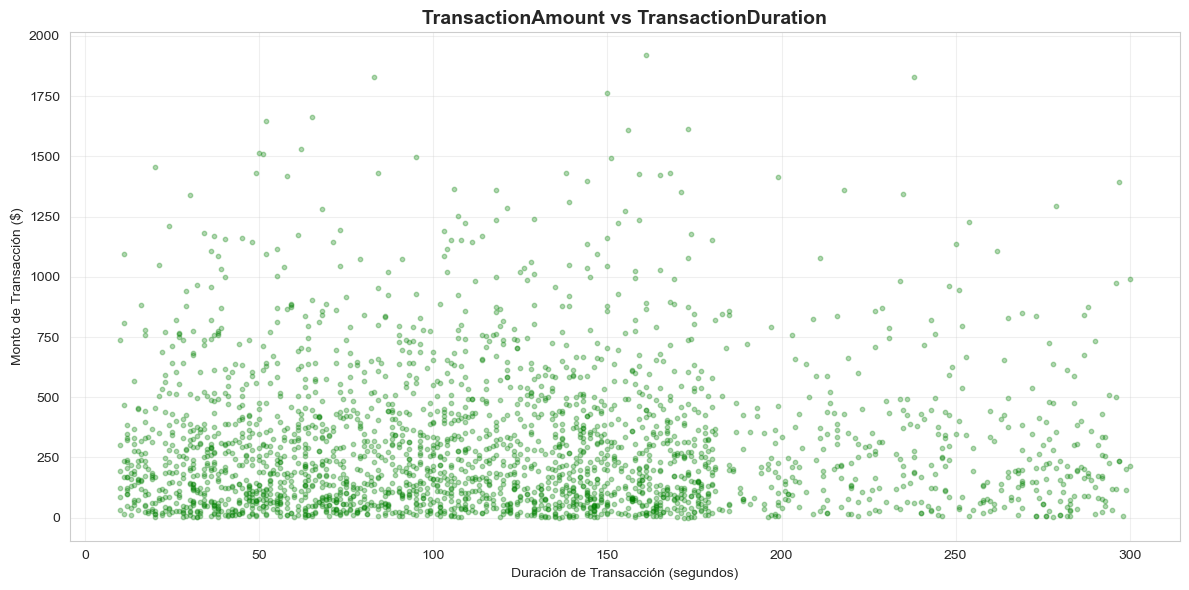


Correlación de Pearson: 0.0044


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df['TransactionDuration'], df['TransactionAmount'], alpha=0.3, s=10, color='green')
ax.set_title('TransactionAmount vs TransactionDuration', fontsize=14, fontweight='bold')
ax.set_xlabel('Duración de Transacción (segundos)')
ax.set_ylabel('Monto de Transacción ($)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlación
corr = df[['TransactionAmount', 'TransactionDuration']].corr().iloc[0, 1]
print(f"\nCorrelación de Pearson: {corr:.4f}")

## Matriz de Correlación: Variables Numéricas

Calculamos la correlación de Pearson entre todas las variables numéricas y visualizamos con heatmap.

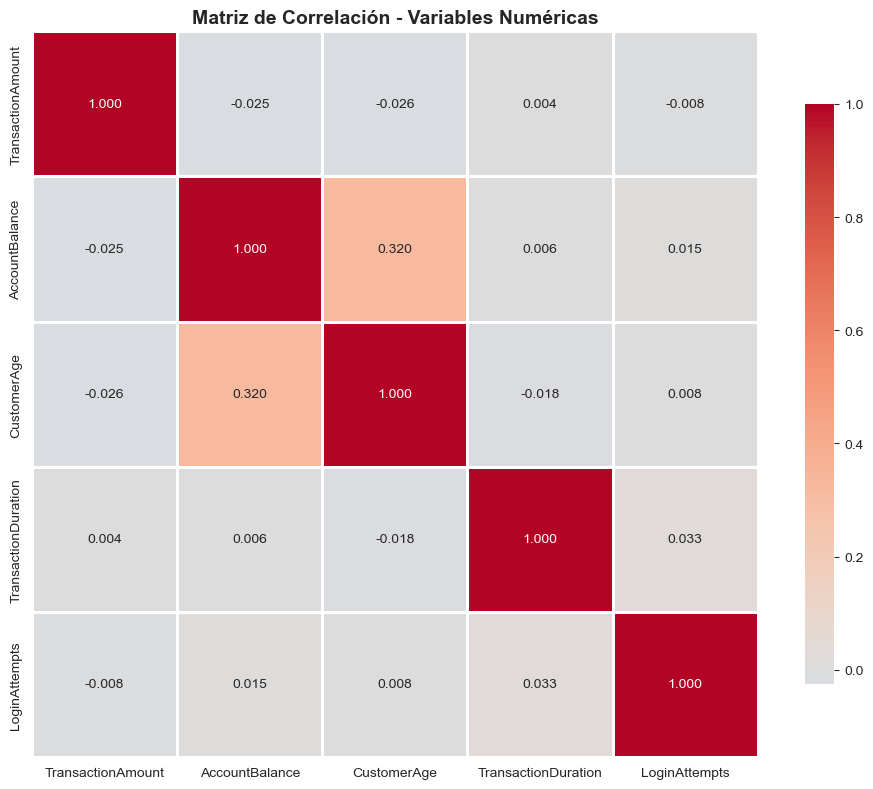


Matriz de Correlación:
                     TransactionAmount  AccountBalance  CustomerAge  \
TransactionAmount             1.000000       -0.025165    -0.025616   
AccountBalance               -0.025165        1.000000     0.319942   
CustomerAge                  -0.025616        0.319942     1.000000   
TransactionDuration           0.004359        0.005577    -0.017936   
LoginAttempts                -0.008445        0.014999     0.007653   

                     TransactionDuration  LoginAttempts  
TransactionAmount               0.004359      -0.008445  
AccountBalance                  0.005577       0.014999  
CustomerAge                    -0.017936       0.007653  
TransactionDuration             1.000000       0.032639  
LoginAttempts                   0.032639       1.000000  


In [11]:
# Variables numéricas
numeric_vars = ['TransactionAmount', 'AccountBalance', 'CustomerAge', 
                'TransactionDuration', 'LoginAttempts']

# Calcular matriz de correlación
corr_matrix = df[numeric_vars].corr()

# Visualizar heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nMatriz de Correlación:")
print(corr_matrix)

# Análisis Bivariado: Categórica vs Categórica

Exploramos las relaciones entre variables categóricas mediante tablas cruzadas y heatmaps.

## Crosstab: Channel vs TransactionType

Analizamos la distribución de tipos de transacción por canal (porcentajes normalizados por fila).

Channel vs TransactionType (% por fila):
TransactionType     Credit      Debit
Channel                              
ATM               8.763505  91.236495
Branch           28.917051  71.082949
Online           30.086313  69.913687


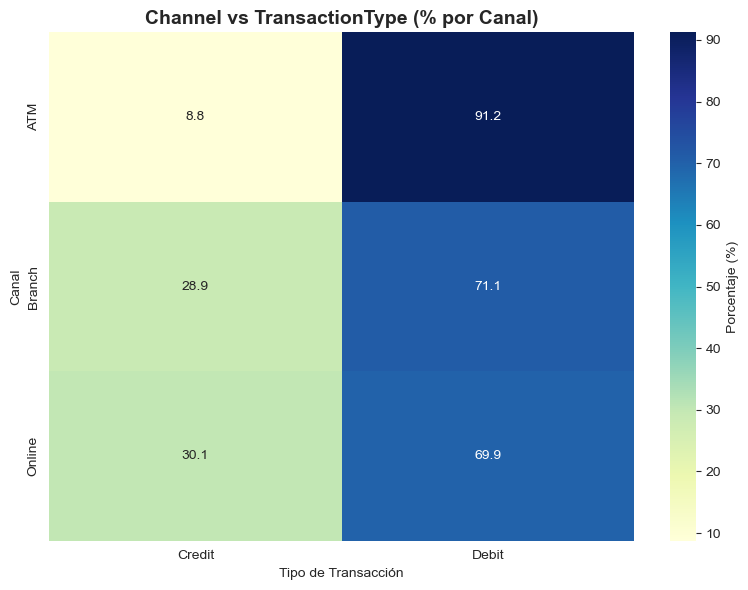

In [12]:
# Tabla cruzada normalizada por fila (porcentajes)
crosstab_channel_type = pd.crosstab(df['Channel'], df['TransactionType'], normalize='index') * 100

print("Channel vs TransactionType (% por fila):")
print(crosstab_channel_type)

# Visualizar con heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(crosstab_channel_type, annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': 'Porcentaje (%)'}, ax=ax)
ax.set_title('Channel vs TransactionType (% por Canal)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Transacción')
ax.set_ylabel('Canal')

plt.tight_layout()
plt.savefig('outputs/figures/channel_vs_type_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## Crosstab: Channel vs CustomerOccupation

Analizamos la distribución de ocupaciones por canal de transacción.

Channel vs CustomerOccupation (% por fila):
CustomerOccupation     Doctor   Engineer    Retired    Student
Channel                                                       
ATM                 25.810324  23.169268  24.369748  26.650660
Branch              25.230415  25.115207  23.847926  25.806452
Online              24.290999  26.387176  23.304562  26.017263


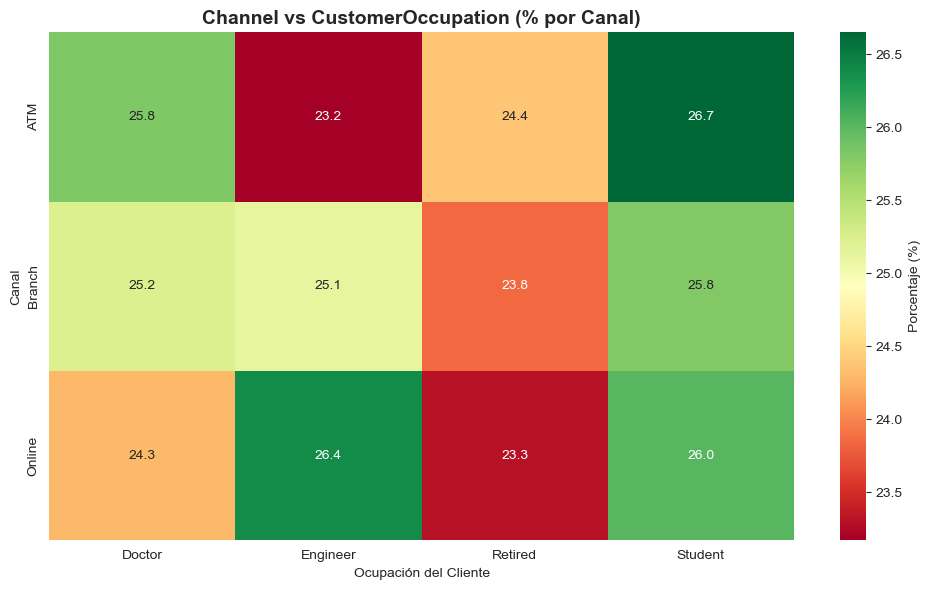

In [13]:
# Tabla cruzada normalizada por fila (porcentajes)
crosstab_channel_occ = pd.crosstab(df['Channel'], df['CustomerOccupation'], normalize='index') * 100

print("Channel vs CustomerOccupation (% por fila):")
print(crosstab_channel_occ)

# Visualizar con heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(crosstab_channel_occ, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Porcentaje (%)'}, ax=ax)
ax.set_title('Channel vs CustomerOccupation (% por Canal)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ocupación del Cliente')
ax.set_ylabel('Canal')

plt.tight_layout()
plt.show()

# Análisis Temporal

Exploramos patrones temporales en las transacciones mediante features derivadas de la fecha.

## Crear Features Temporales

Extraemos hora, día de la semana y mes de la fecha de transacción.

In [14]:
# Extraer features temporales
df['hour'] = df['TransactionDate_dt'].dt.hour
df['dayofweek'] = df['TransactionDate_dt'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['month'] = df['TransactionDate_dt'].dt.month

print("✓ Features temporales creadas:")
print(f"  - hour: rango {df['hour'].min()} a {df['hour'].max()}")
print(f"  - dayofweek: rango {df['dayofweek'].min()} a {df['dayofweek'].max()}")
print(f"  - month: rango {df['month'].min()} a {df['month'].max()}")

✓ Features temporales creadas:
  - hour: rango 16 a 18
  - dayofweek: rango 0 a 4
  - month: rango 1 a 12


## TransactionAmount por Hora del Día

Analizamos cómo varía el monto de transacciones según la hora del día.

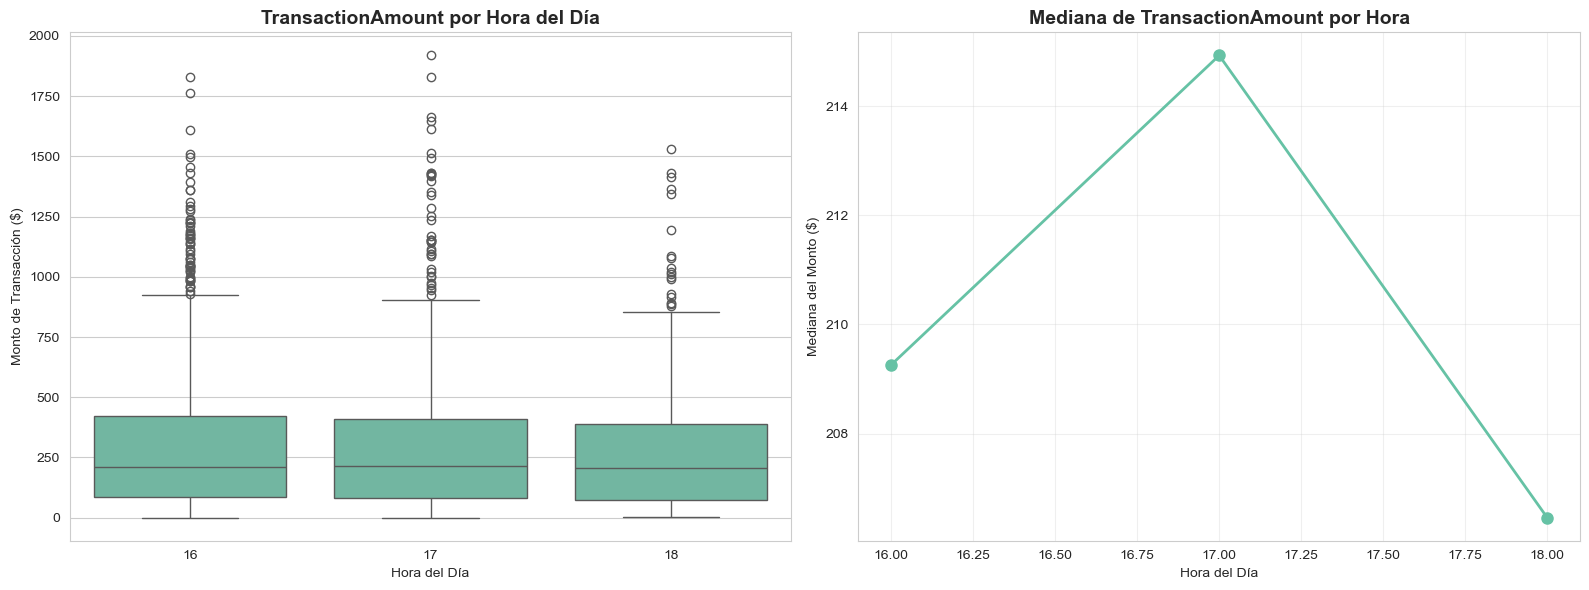

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por hora
sns.boxplot(data=df.dropna(subset=['hour']), x='hour', y='TransactionAmount', ax=axes[0])
axes[0].set_title('TransactionAmount por Hora del Día', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hora del Día')
axes[0].set_ylabel('Monto de Transacción ($)')

# Línea de mediana por hora
median_by_hour = df.groupby('hour')['TransactionAmount'].median()
axes[1].plot(median_by_hour.index, median_by_hour.values, marker='o', linewidth=2, markersize=8)
axes[1].set_title('Mediana de TransactionAmount por Hora', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hora del Día')
axes[1].set_ylabel('Mediana del Monto ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Volumen de Transacciones por Mes

Analizamos el número de transacciones por mes para identificar patrones estacionales.

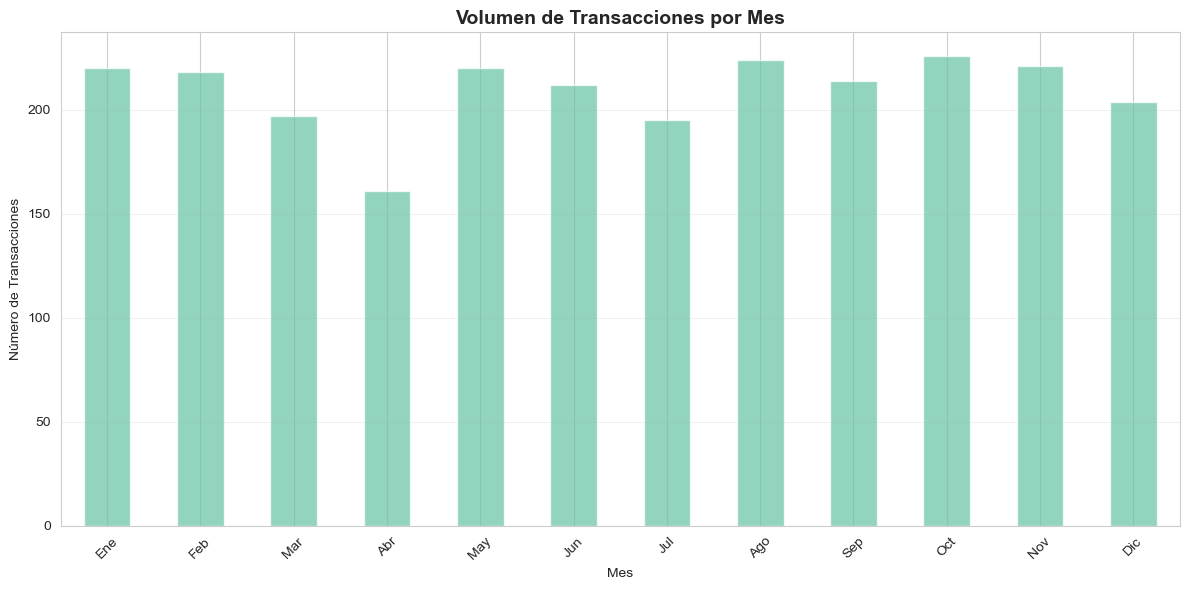


Volumen por mes:
month
1     220
2     218
3     197
4     161
5     220
6     212
7     195
8     224
9     214
10    226
11    221
12    204
dtype: int64


In [16]:
# Contar transacciones por mes
volume_by_month = df.groupby('month').size()

fig, ax = plt.subplots(figsize=(12, 6))
volume_by_month.plot(kind='bar', ax=ax, alpha=0.7)
ax.set_title('Volumen de Transacciones por Mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de Transacciones')
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'][:len(volume_by_month)], 
                   rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/volume_by_month.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVolumen por mes:")
print(volume_by_month)

# Rankings Exploratorios

Identificamos los principales actores y patrones mediante rankings de diferentes variables.

## Top 10 Ubicaciones por Monto Promedio

Identificamos las ubicaciones con los montos de transacción más altos (mediana).

Top 10 Ubicaciones por Monto Mediano:
                  Mediana  Promedio  N_Transacciones
Location                                            
San Jose           307.24    341.15               59
El Paso            285.37    369.51               46
Washington         268.04    351.03               48
Jacksonville       261.97    341.99               60
Austin             259.49    385.44               59
San Antonio        258.21    327.51               59
Mesa               251.80    314.16               61
Kansas City        250.01    307.68               61
Portland           247.21    338.62               42
Colorado Springs   240.68    339.08               60


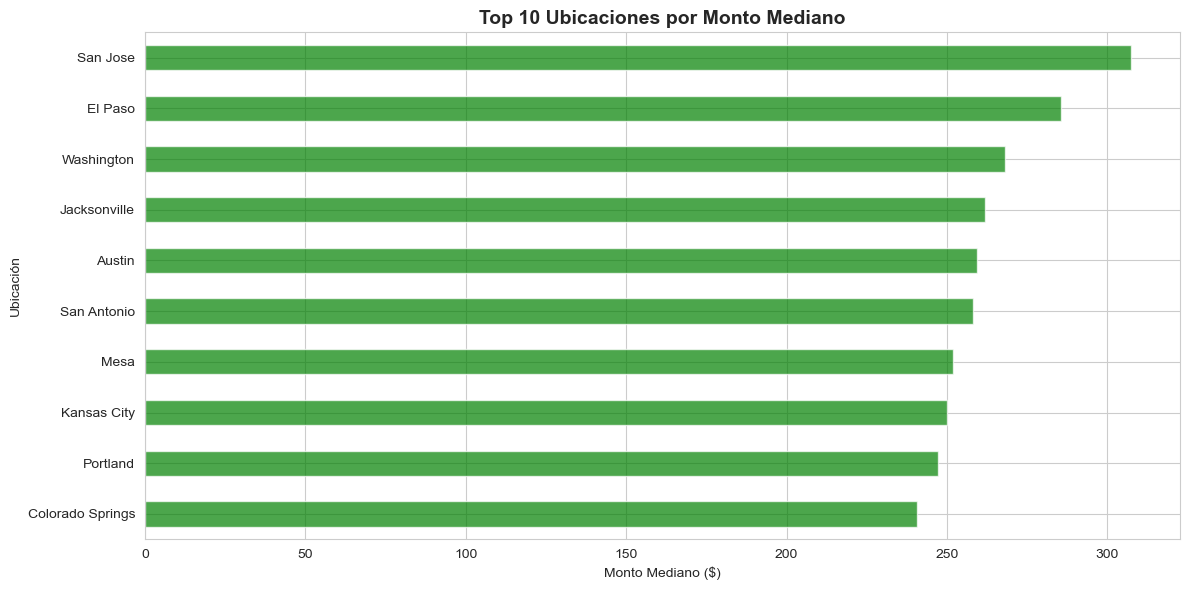

In [17]:
# Calcular mediana y conteo por ubicación
location_stats = df.groupby('Location').agg({
    'TransactionAmount': ['median', 'mean', 'count']
}).round(2)
location_stats.columns = ['Mediana', 'Promedio', 'N_Transacciones']
location_stats = location_stats.sort_values('Mediana', ascending=False).head(10)

print("Top 10 Ubicaciones por Monto Mediano:")
print(location_stats)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
location_stats['Mediana'].plot(kind='barh', ax=ax, color='green', alpha=0.7)
ax.set_title('Top 10 Ubicaciones por Monto Mediano', fontsize=14, fontweight='bold')
ax.set_xlabel('Monto Mediano ($)')
ax.set_ylabel('Ubicación')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Top 10 Comerciantes por Monto Mediano

Identificamos los comerciantes con los montos de transacción más altos.

Top 10 Comerciantes por Monto Mediano:
            Mediana  Promedio  N_Transacciones
MerchantID                                    
M048         397.97    421.34               26
M075         389.05    465.59               19
M081         345.39    441.51               23
M051         327.86    292.34               23
M054         327.80    349.36               27
M038         326.03    336.89               31
M086         325.98    393.59               21
M006         316.13    383.87               16
M018         308.80    374.73               27
M010         304.15    320.09               19


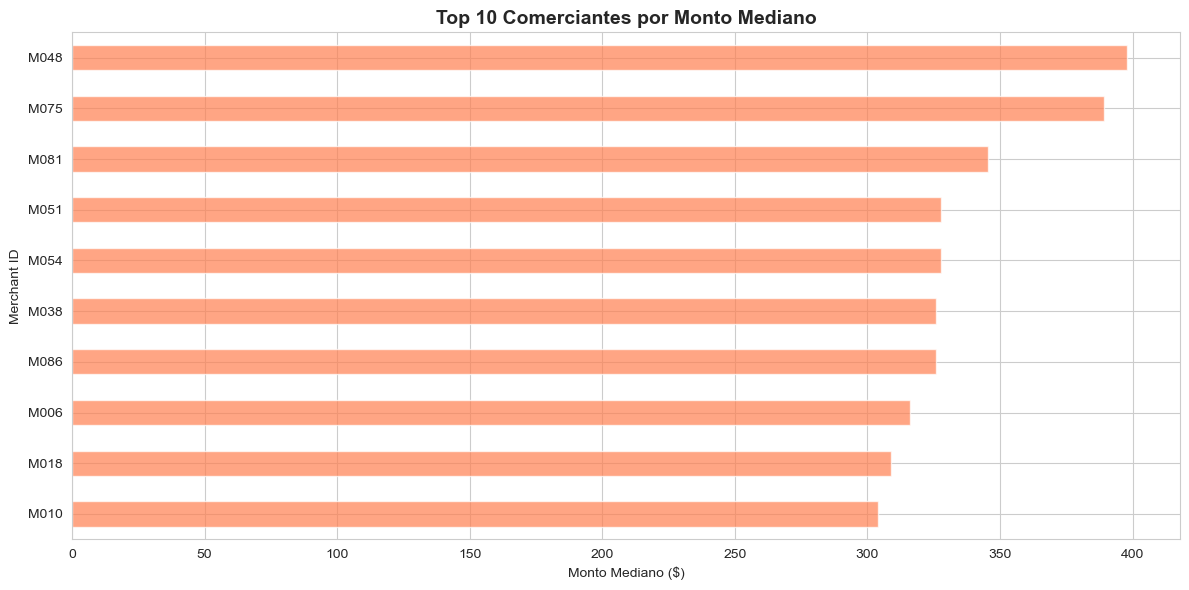

In [18]:
# Calcular mediana y conteo por comerciante
merchant_stats = df.groupby('MerchantID').agg({
    'TransactionAmount': ['median', 'mean', 'count']
}).round(2)
merchant_stats.columns = ['Mediana', 'Promedio', 'N_Transacciones']
merchant_stats = merchant_stats.sort_values('Mediana', ascending=False).head(10)

print("Top 10 Comerciantes por Monto Mediano:")
print(merchant_stats)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
merchant_stats['Mediana'].plot(kind='barh', ax=ax, color='coral', alpha=0.7)
ax.set_title('Top 10 Comerciantes por Monto Mediano', fontsize=14, fontweight='bold')
ax.set_xlabel('Monto Mediano ($)')
ax.set_ylabel('Merchant ID')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Top 10 Cuentas por Monto Máximo

Identificamos las cuentas con las transacciones de mayor monto individual.

Top 10 Cuentas por Monto Máximo:
            Máximo  Mediana  N_Transacciones
AccountID                                   
AC00423    1919.11   254.49                6
AC00179    1831.02   288.02                6
AC00107    1830.00   345.54                5
AC00358    1762.28   350.37                8
AC00028    1664.33   398.36                3
AC00071    1647.74   439.38                8
AC00338    1612.37   153.08                7
AC00460    1607.55   405.31               12
AC00083    1531.31   300.94                6
AC00303    1512.99   214.60                6


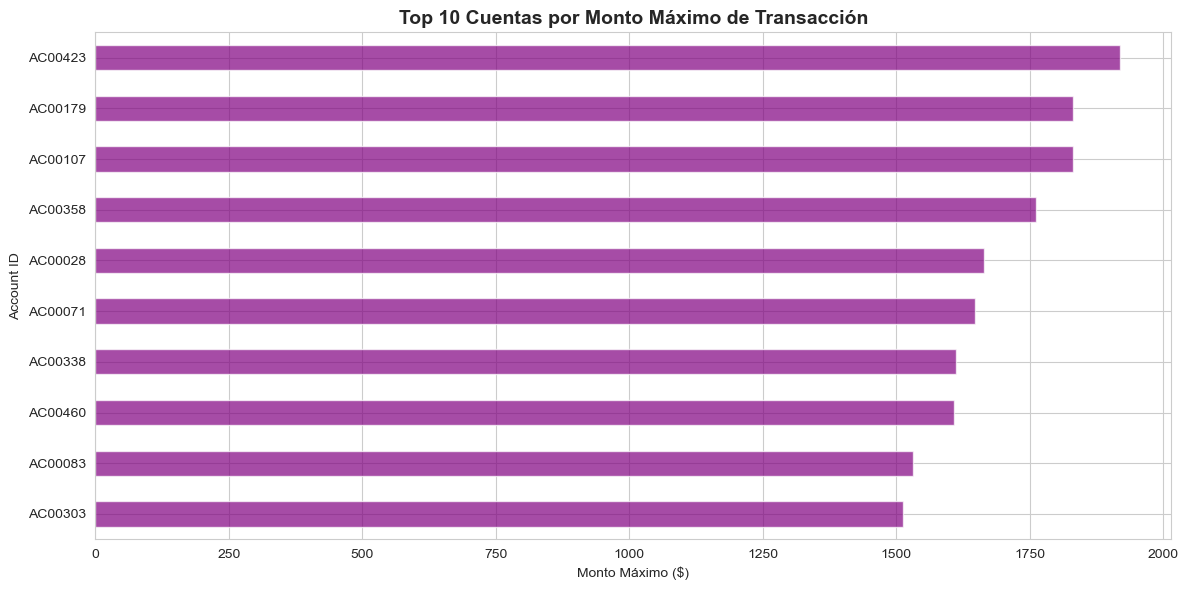

In [19]:
# Calcular máximo y conteo por cuenta
account_stats = df.groupby('AccountID').agg({
    'TransactionAmount': ['max', 'median', 'count']
}).round(2)
account_stats.columns = ['Máximo', 'Mediana', 'N_Transacciones']
account_stats = account_stats.sort_values('Máximo', ascending=False).head(10)

print("Top 10 Cuentas por Monto Máximo:")
print(account_stats)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
account_stats['Máximo'].plot(kind='barh', ax=ax, color='purple', alpha=0.7)
ax.set_title('Top 10 Cuentas por Monto Máximo de Transacción', fontsize=14, fontweight='bold')
ax.set_xlabel('Monto Máximo ($)')
ax.set_ylabel('Account ID')
ax.invert_yaxis()

plt.tight_layout()
plt.show()